<a href="https://colab.research.google.com/github/RafiShiddik/Project/blob/main/predict_how_satisfied_customers_are_in_detail_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install factor-analyzer

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.max_column', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


%matplotlib inline

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pd.set_option('display.max_column', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('/content/customer_feedback_satisfaction.csv')
df.head()

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


In [ ]:
pip install pycountry

In [ ]:
from functools import lru_cache
import pycountry

@lru_cache(maxsize=512)
def country_lookup(code):
    if not code or pd.isna(code):
        return None  # langsung berhenti jika None / NaN / kosong

    code = code.strip().upper()
    try:
        country = pycountry.countries.get(alpha_2=code) or pycountry.countries.get(alpha_3=code)
        if country:
            return country.name
        matches = pycountry.countries.search_fuzzy(code)
        if matches:
            return matches[0].name
    except Exception:
        return None
    return None


In [ ]:
df['Country_fact'] = df['Country'].fillna('').apply(country_lookup)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
 11  Country_fact       38444 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 3.5+ MB


In [ ]:
df['Country_fact'].head()

,Country_fact
0,Uganda
1,Uganda
2,United States
3,Uganda
4,Uganda


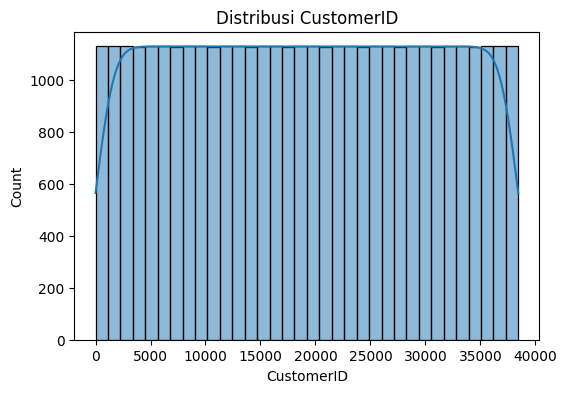

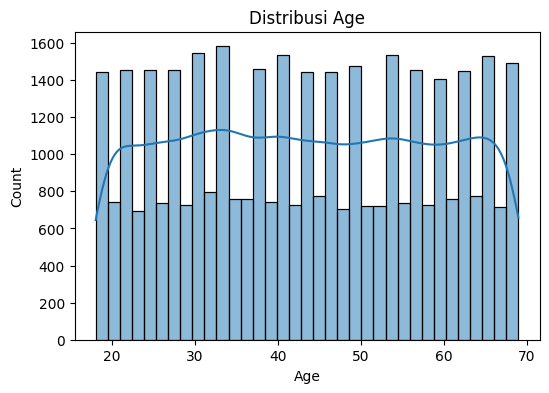

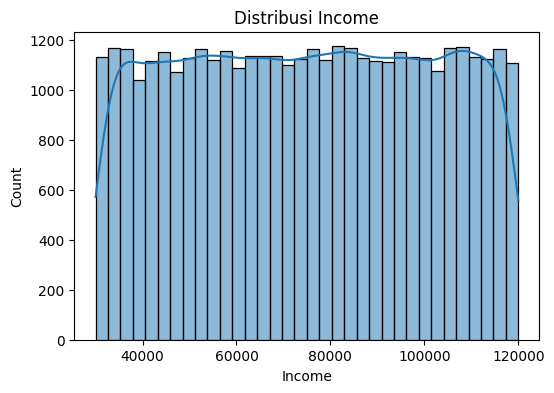

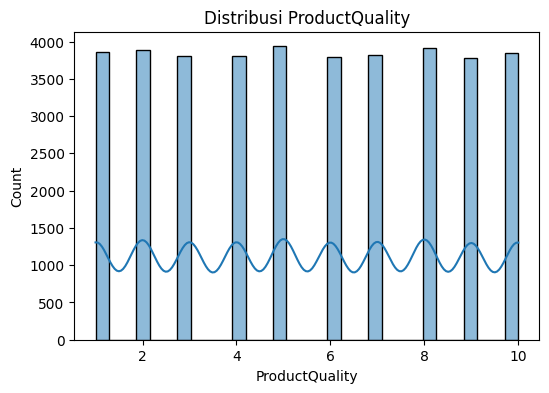

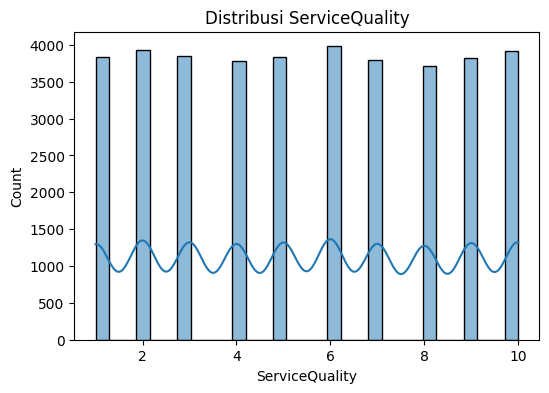

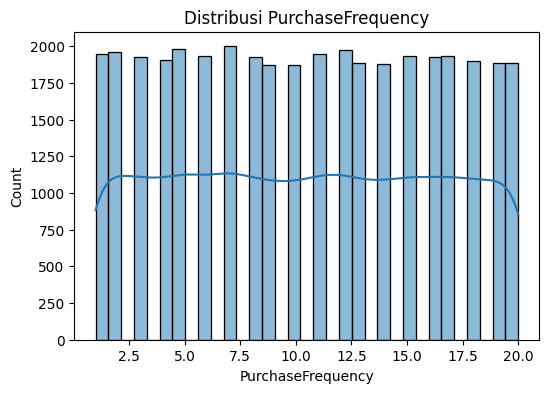

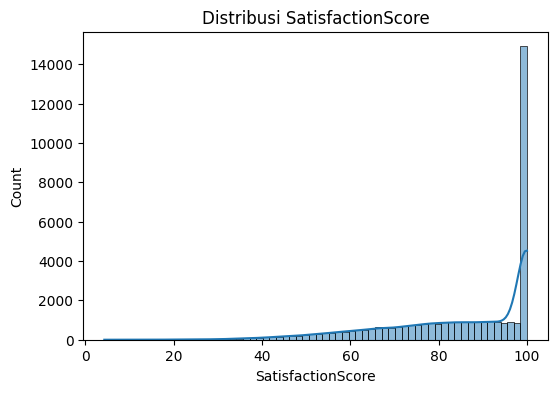

In [ ]:
#mengecek distribusi data dari beberapa column numerik
import seaborn as sns

for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

In [ ]:
#df copy untuk melihat apakah ini sudah di clean dengan benar shingga data aslinya tidak terganti jika ini eror
def remove_outliers_iqr(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include='number').columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df_no_outliers = remove_outliers_iqr(df)

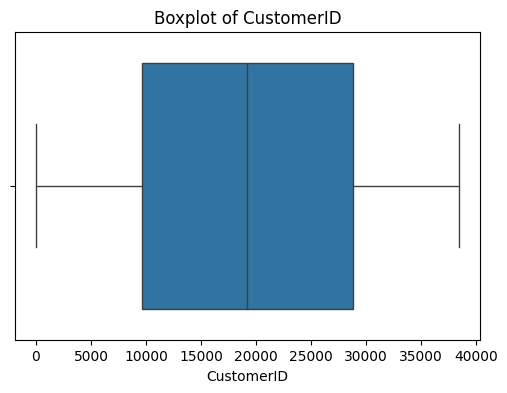

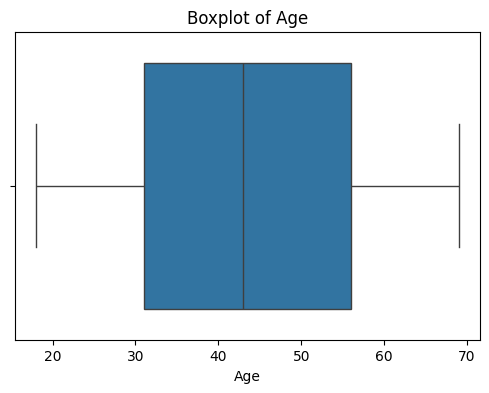

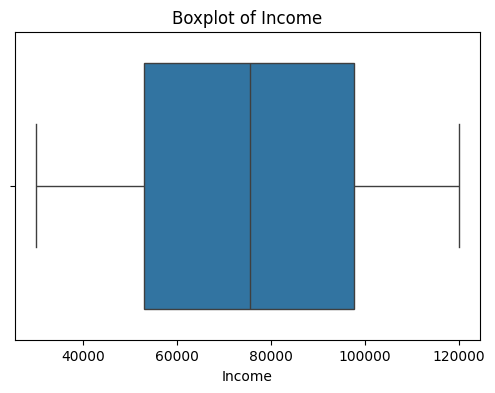

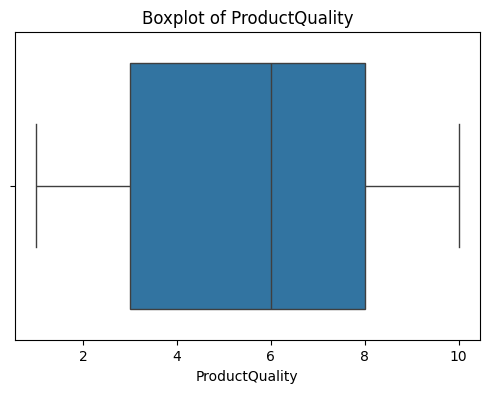

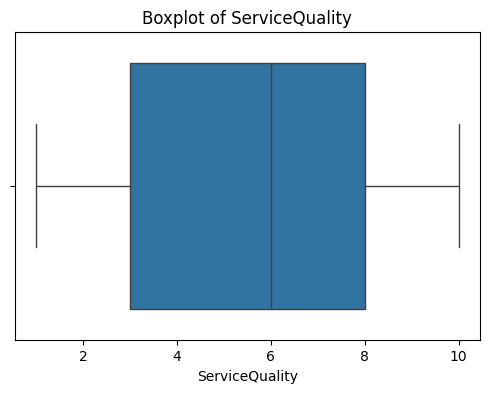

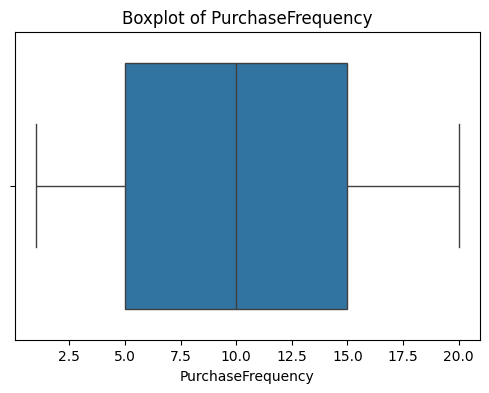

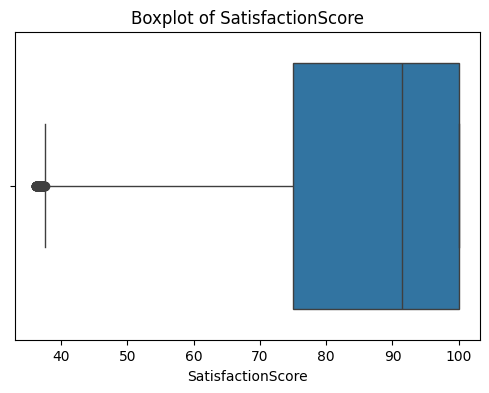

In [ ]:
# Visualisasi boxplot semua kolom numerik tanpa outlier
for col in df_no_outliers.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_no_outliers[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

karena score staficasion ini penting dan perilaku customer jadi biarkan saja tidak perlu di handling

In [ ]:
import numpy as np

# Tambahkan 1 untuk menghindari log(0)
df_no_outliers['SatisfactionScore_log'] = np.log1p(df_no_outliers['SatisfactionScore'])

In [ ]:
def group_satisfaction(score):
    if score >= 90:
        return 'Very High'
    elif score >= 70:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

df_no_outliers['Satisfaction_Level'] = df_no_outliers['SatisfactionScore'].apply(group_satisfaction)

In [ ]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38132 entries, 0 to 38443
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             38132 non-null  int64  
 1   Age                    38132 non-null  int64  
 2   Gender                 38132 non-null  object 
 3   Country                38132 non-null  object 
 4   Income                 38132 non-null  int64  
 5   ProductQuality         38132 non-null  int64  
 6   ServiceQuality         38132 non-null  int64  
 7   PurchaseFrequency      38132 non-null  int64  
 8   FeedbackScore          38132 non-null  object 
 9   LoyaltyLevel           38132 non-null  object 
 10  SatisfactionScore      38132 non-null  float64
 11  Country_fact           38132 non-null  object 
 12  SatisfactionScore_log  38132 non-null  float64
 13  Satisfaction_Level     38132 non-null  object 
dtypes: float64(2), int64(6), object(6)
memory usage: 4.4+ MB


#Label Wncoder

In [ ]:
df_no_outliers.drop(columns=['Country'], inplace=True)

In [ ]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38132 entries, 0 to 38443
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             38132 non-null  int64  
 1   Age                    38132 non-null  int64  
 2   Gender                 38132 non-null  object 
 3   Income                 38132 non-null  int64  
 4   ProductQuality         38132 non-null  int64  
 5   ServiceQuality         38132 non-null  int64  
 6   PurchaseFrequency      38132 non-null  int64  
 7   FeedbackScore          38132 non-null  object 
 8   LoyaltyLevel           38132 non-null  object 
 9   SatisfactionScore      38132 non-null  float64
 10  Country_fact           38132 non-null  object 
 11  SatisfactionScore_log  38132 non-null  float64
 12  Satisfaction_Level     38132 non-null  object 
dtypes: float64(2), int64(6), object(5)
memory usage: 4.1+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_no_outliers['Gender'] = le.fit_transform(df_no_outliers['Gender'])
df_no_outliers['FeedbackScore'] = le.fit_transform(df_no_outliers['FeedbackScore'])
df_no_outliers['LoyaltyLevel'] = le.fit_transform(df_no_outliers['LoyaltyLevel'])
df_no_outliers['Country_fact'] = le.fit_transform(df_no_outliers['Country_fact'])
df_no_outliers['Satisfaction_Level'] = le.fit_transform(df_no_outliers['Satisfaction_Level'])


In [ ]:
df_no_outliers.head()

,CustomerID,Age,Gender,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore,Country_fact,SatisfactionScore_log,Satisfaction_Level
0,1,56,1,83094,5,8,5,1,0,100.0,3,4.615121,3
1,2,69,1,86860,10,2,8,2,1,100.0,3,4.615121,3
2,3,46,0,60173,8,10,18,2,2,100.0,4,4.615121,3
3,4,32,0,73884,7,10,16,1,1,100.0,3,4.615121,3
4,5,60,1,97546,6,4,13,1,0,82.0,3,4.418841,0


In [ ]:
# Melihat korelasi antar variabel numerik
correlation_matrix = df_no_outliers.corr(numeric_only=True)  # df adalah nama DataFrame kamu
print(correlation_matrix)

                       CustomerID       Age    Gender    Income  \
CustomerID               1.000000  0.001839  0.001298 -0.004930   
Age                      0.001839  1.000000 -0.002482 -0.004115   
Gender                   0.001298 -0.002482  1.000000  0.002617   
Income                  -0.004930 -0.004115  0.002617  1.000000   
ProductQuality          -0.004788 -0.015131  0.000051 -0.011529   
ServiceQuality           0.008415 -0.001096 -0.002936 -0.004429   
PurchaseFrequency        0.005256 -0.005577 -0.001546 -0.001502   
FeedbackScore            0.003592 -0.002769  0.002891  0.007782   
LoyaltyLevel            -0.001145 -0.007182  0.000887  0.001150   
SatisfactionScore        0.002282  0.149406 -0.004565  0.231729   
Country_fact             0.000803  0.005611  0.003819 -0.008715   
SatisfactionScore_log    0.002142  0.147652 -0.004655  0.226478   
Satisfaction_Level       0.002158  0.096979  0.001874  0.153938   

                       ProductQuality  ServiceQuality  Purcha

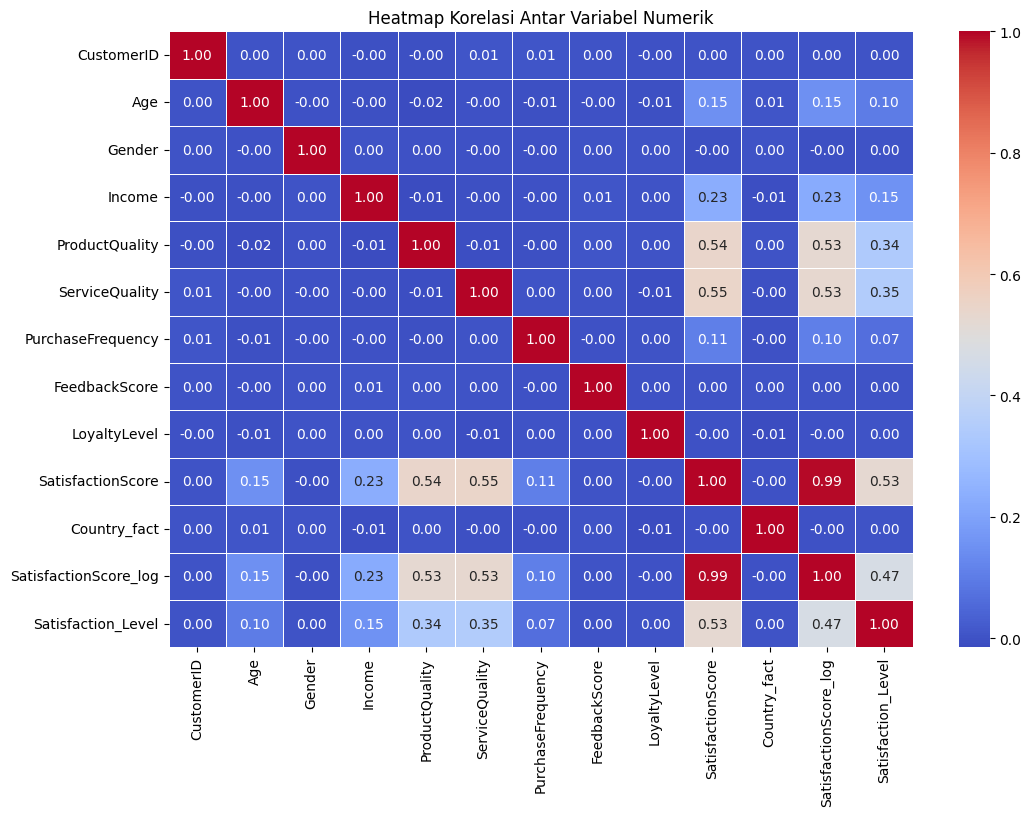

In [ ]:
# Atur ukuran heatmap
plt.figure(figsize=(12, 8))

# Buat heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Judul heatmap
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

In [ ]:
df['CustomerID'].nunique()

38444

Stafication log dan score sangat tinggi ini karena stafication log merupakan transformasi dari stafication score sendiri jadi normal jika nilainya tinggi

#Model KNN

In [ ]:
x = df_no_outliers.drop(columns=['CustomerID', 'SatisfactionScore', 'SatisfactionScore_log'])  # atau simpan log saja
y = df_no_outliers['SatisfactionScore_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.5,
    random_state = 42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)  # kamu bisa tuning nilai K
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [ ]:
y_pred = knn.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)


MSE: 0.007397606218539429
R2 Score: 0.8397084987149808


In [ ]:
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

In [ ]:
pip install optuna

In [ ]:
import optuna
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df_no_outliers.drop(columns=['CustomerID', 'SatisfactionScore', 'SatisfactionScore_log'])  # atau simpan log saja
y = df_no_outliers['SatisfactionScore_log']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])

    model = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        algorithm=algorithm
    )

    # Cross-validation untuk stabilitas skor
    score = cross_val_score(model, X_scaled, y, cv=5, scoring='r2').mean()
    return score


In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Ubah jumlah trial sesuai waktu/kebutuhan

[I 2025-06-16 09:02:21,253] A new study created in memory with name: no-name-9336fcec-2bff-4959-a655-2cac724152a6
[I 2025-06-16 09:02:34,628] Trial 0 finished with value: 0.8583649130038224 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'algorithm': 'auto'}. Best is trial 0 with value: 0.8583649130038224.
[I 2025-06-16 09:02:51,851] Trial 1 finished with value: 0.853156472189102 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 0 with value: 0.8583649130038224.
[I 2025-06-16 09:03:05,309] Trial 2 finished with value: 0.862959099765239 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 2 with value: 0.862959099765239.
[I 2025-06-16 09:03:21,648] Trial 3 finished with value: 0.8625484287517834 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'algorithm': 'brute'}. Best is trial 2 with value: 0.862959099765239.
[I 2025-06-16 09:03:34,139] Trial 4 finished with value: 0.86064365439

In [ ]:
print("Best trial:")
print(study.best_trial)

print("Best params:")
print(study.best_params)

Best trial:
FrozenTrial(number=11, state=1, values=[0.863156143579414], datetime_start=datetime.datetime(2025, 6, 16, 9, 4, 33, 115339), datetime_complete=datetime.datetime(2025, 6, 16, 9, 4, 40, 347875), params={'n_neighbors': 11, 'weights': 'distance', 'algorithm': 'kd_tree'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_neighbors': IntDistribution(high=30, log=False, low=3, step=1), 'weights': CategoricalDistribution(choices=('uniform', 'distance')), 'algorithm': CategoricalDistribution(choices=('auto', 'ball_tree', 'kd_tree', 'brute'))}, trial_id=11, value=None)
Best params:
{'n_neighbors': 11, 'weights': 'distance', 'algorithm': 'kd_tree'}


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_params = study.best_params

best_knn = KNeighborsRegressor(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    algorithm=best_params['algorithm']
)

# Split dan scale ulang jika belum:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 0.006319943229360997
RMSE: 0.0794980706014995
MAE: 0.04918087199102087
R2 Score: 0.8621556652777009


Model KNN Regressor kamu yang dituning dengan Optuna menghasilkan performa sangat baik dalam memprediksi SatisfactionScore_log.
Model kamu stabil, akurat, dan fit dengan data.

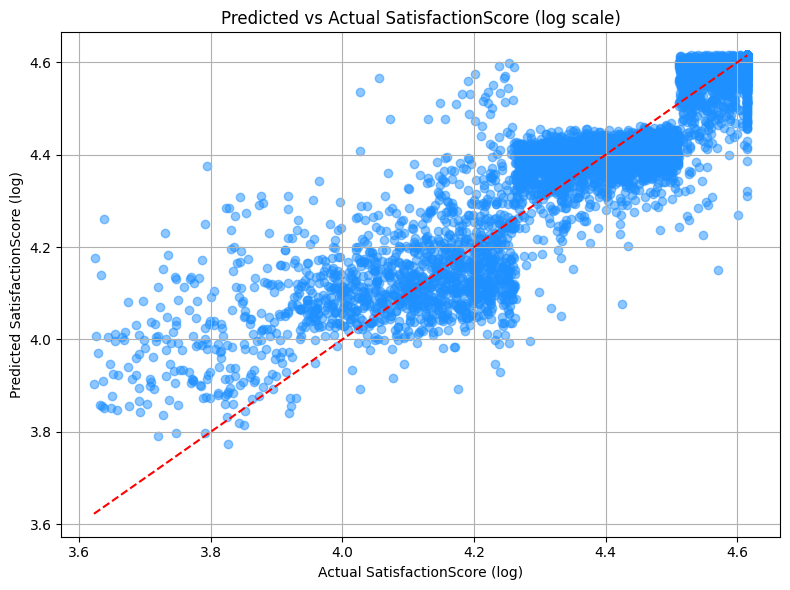

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SatisfactionScore (log)')
plt.ylabel('Predicted SatisfactionScore (log)')
plt.title('Predicted vs Actual SatisfactionScore (log scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

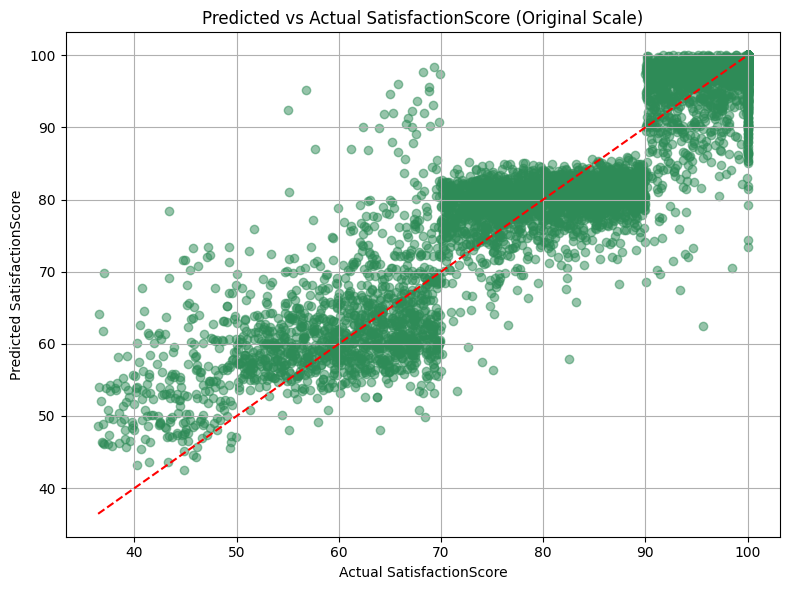

In [ ]:
# Konversi dari log ke skala asli
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='seagreen')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xlabel('Actual SatisfactionScore')
plt.ylabel('Predicted SatisfactionScore')
plt.title('Predicted vs Actual SatisfactionScore (Original Scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

Bagus! Hasil evaluasi regresi kamu cukup kuat. Mari kita bahas arti dari masing-masing metrik di bawah:

📊 Hasil Evaluasi:
1. MSE (Mean Squared Error): 0.0063
Ini adalah rata-rata dari kuadrat selisih antara prediksi dan nilai asli.

Makin kecil, makin baik.

Karena kamu menggunakan SatisfactionScore_log sebagai target, maka MSE ini dalam skala logaritmik.

Nilai 0.0063 termasuk kecil, yang menunjukkan prediksi cukup akurat.

2. RMSE (Root Mean Squared Error): 0.0795
Ini adalah akar dari MSE → satuannya sama seperti target (SatisfactionScore_log).

RMSE memperbesar penalti untuk error yang besar.

Nilai 0.0795 menunjukkan error prediksi log-skor kamu relatif kecil.

3. MAE (Mean Absolute Error): 0.0492)
Rata-rata selisih absolut antara prediksi dan nilai asli.

Tidak terlalu sensitif terhadap outlier dibanding RMSE.

Nilai 0.0492 juga cukup rendah, artinya prediksi kamu secara umum dekat dengan nilai asli (dalam domain log).

4. R² Score: 0.8622
Mengukur seberapa baik model menjelaskan variasi data target.

Skala dari 0 (model buruk) ke 1 (model sempurna).

Nilai 0.8622 berarti model menjelaskan 86.2% variansi dari data target.

Ini adalah nilai yang sangat baik untuk model regresi!

📝 Kesimpulan Interpretasi:
✅ Model KNN Regressor kamu yang dituning dengan Optuna menghasilkan performa sangat baik dalam memprediksi SatisfactionScore_log.
Model kamu stabil, akurat, dan fit dengan data.

Semakin rapat titik-titik berada di garis merah putus-putus (garis y = x), maka semakin akurat prediksinya.

Sebaran titik yang terlalu menyebar jauh dari garis tersebut mengindikasikan prediksi kurang tepat.

#Model Decesion Tree

In [ ]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
def objective(trial):
    # Hyperparameter yang akan dicoba oleh Optuna
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Model dengan parameter dari trial
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Cross-validation untuk akurasi yang stabil
    score = cross_val_score(model, X_train, y_train,
                            scoring='neg_mean_squared_error',
                            cv=5)

    return -1 * score.mean()  # karena score negatif

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)  # kamu bisa ubah jumlah trial sesuai kebutuhan

[I 2025-06-16 09:09:51,675] A new study created in memory with name: no-name-3fe1b471-ede9-4aac-a260-a714360a2f37
[I 2025-06-16 09:09:53,219] Trial 0 finished with value: 0.004091076643291409 and parameters: {'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.004091076643291409.
[I 2025-06-16 09:09:54,372] Trial 1 finished with value: 0.003709485538758178 and parameters: {'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.003709485538758178.
[I 2025-06-16 09:09:55,837] Trial 2 finished with value: 0.0035527404485157744 and parameters: {'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.0035527404485157744.
[I 2025-06-16 09:09:57,582] Trial 3 finished with value: 0.0030456877845484497 and parameters: {'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 3 with value: 0.0030456877845484497.
[I 2025-06-16 09:09:58,440] Trial 4 finis

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Ambil parameter terbaik
best_params = study.best_params

# Latih model dengan parameter terbaik
best_tree = DecisionTreeRegressor(
    **best_params,
    random_state=42
)

best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)

# Evaluasi
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Cetak hasil evaluasi
print("Best Hyperparameters:", best_params)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


Best Hyperparameters: {'max_depth': 8, 'min_samples_split': 20, 'min_samples_leaf': 5}
MSE : 0.0029339199547192703
RMSE: 0.05416567136775165
MAE : 0.03777193404313878
R2  : 0.936008247288062


In [ ]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

Bagian Atas: Optimization History
📈 Grafik:
Titik biru = Nilai objektif (MSE) dari masing-masing percobaan (trial)

Garis merah = Best value sejauh ini (nilai MSE terbaik yang ditemukan)

🔍 Makna:
Awalnya, model punya error tinggi (sekitar 0.0045 hingga 0.006)

Lalu dengan cepat menemukan parameter yang menurunkan error menjadi sekitar 0.003

Setelah itu performa model cenderung stabil, artinya Optuna sudah menemukan titik optimal di awal dan hanya sedikit perbaikan di trial berikutnya

🟢 Kesimpulan: Model sudah cukup baik dan stabil di bawah MSE ≈ 0.003

🔽 Bagian Bawah: Hyperparameter Importances
📊 Bar Chart:
Menunjukkan seberapa besar pengaruh masing-masing parameter terhadap hasil tuning

max_depth sangat dominan → berkontribusi 97% terhadap performa model

min_samples_split dan min_samples_leaf hanya menyumbang sangat sedikit (2% dan 1%)

🔍 Makna:
max_depth adalah hyperparameter yang paling kritikal dalam mengatur kualitas pohon regresi

Perlu fokus pada max_depth saat menyederhanakan tuning atau eksplorasi manual



#Random Forest

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Misalnya df adalah DataFrame final kamu
X = df_no_outliers.drop(columns=['SatisfactionScore', 'SatisfactionScore_log'])
y = df_no_outliers['SatisfactionScore_log']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Objective function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = RandomForestRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2025-06-16 09:10:35,388] A new study created in memory with name: no-name-1205aa32-04e4-4f7e-994a-8ab960046cd3
[I 2025-06-16 09:11:10,954] Trial 0 finished with value: 0.0027363044843608905 and parameters: {'n_estimators': 248, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.0027363044843608905.
[I 2025-06-16 09:11:22,456] Trial 1 finished with value: 0.002978727636502787 and parameters: {'n_estimators': 271, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0027363044843608905.
[I 2025-06-16 09:11:44,322] Trial 2 finished with value: 0.0027410846803929715 and parameters: {'n_estimators': 171, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.0027363044843608905.
[I 2025-06-16 09:11:48,655] Trial 3 finished with value: 0.002928971630279431 and parameters: {'n_estimators': 101, 'ma

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Bangun model lagi dengan best params dari Optuna
best_params = study.best_params

best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

# Hitung semua metrik
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Tampilkan
print("Evaluasi Model Terbaik:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

Evaluasi Model Terbaik:
MSE : 0.0027352409520275565
RMSE: 0.05229953108802751
MAE : 0.03643231919216045


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gunakan parameter terbaik dari Optuna
best_params = study.best_params

# Buat dan latih model akhir
final_rf = RandomForestRegressor(**best_params, random_state=42)
final_rf.fit(X_train, y_train)

# Prediksi
y_pred = final_rf.predict(X_test)

# Evaluasi
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Evaluasi Model Random Forest")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

✅ Evaluasi Model Random Forest
MSE: 0.0027352409520275565
RMSE: 0.05229953108802751
MAE: 0.03643231919216045
R2 Score: 0.9403416366802477


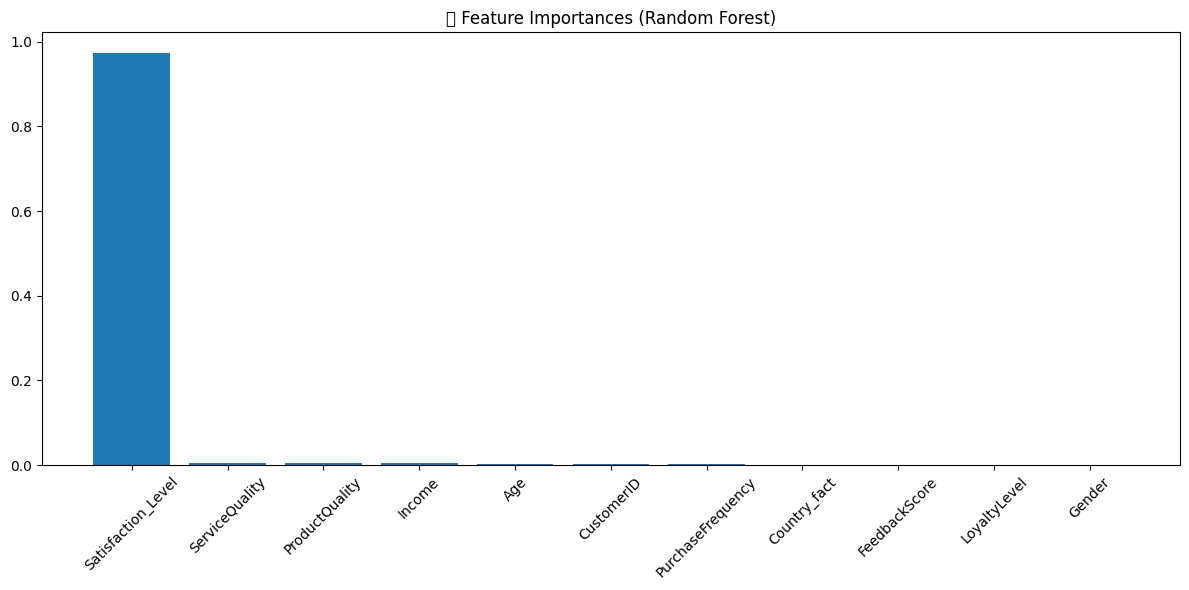

In [ ]:
# Visualisasi feature importance
importances = final_rf.feature_importances_
feature_names = X.columns

# Urutkan
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("🔍 Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

#tanpa stafication level

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Drop 'Satisfaction_Level' dari X
X_filtered = X.drop('Satisfaction_Level', axis=1)

# Definisikan objective function untuk Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = RandomForestRegressor(**params, random_state=42)
    model.fit(X_train_filtered, y_train)  # gunakan data yang sudah difilter

    preds = model.predict(X_test_filtered)
    mse = mean_squared_error(y_test, preds)

    return mse

# Split ulang jika belum
from sklearn.model_selection import train_test_split
X_train_filtered, X_test_filtered, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Jalankan Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Evaluasi model terbaik
best_params = study.best_params
print("Best Parameters:", best_params)

# Train model terbaik
best_model = RandomForestRegressor(**best_params, random_state=42)
best_model.fit(X_train_filtered, y_train)

y_pred = best_model.predict(X_test_filtered)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

[I 2025-06-16 09:29:25,822] A new study created in memory with name: no-name-aa241635-6132-4b41-9861-c4b8878f2a07
[I 2025-06-16 09:29:28,818] Trial 0 finished with value: 0.013811225817439569 and parameters: {'n_estimators': 110, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.013811225817439569.
[I 2025-06-16 09:29:39,230] Trial 1 finished with value: 0.011725756165775867 and parameters: {'n_estimators': 62, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 1 with value: 0.011725756165775867.
[I 2025-06-16 09:29:42,967] Trial 2 finished with value: 0.012197796955277153 and parameters: {'n_estimators': 114, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.011725756165775867.
[I 2025-06-16 09:29:48,511] Trial 3 finished with value: 0.01155219727973983 and parameters: {'n_estimators': 114, 'max_depth

Best Parameters: {'n_estimators': 159, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': None}
MSE: 0.011231388259339526
RMSE: 0.10597824427371651
MAE: 0.07074875992387362
R2 Score: 0.7550320965821344


🎯 Makna Grafik:
Satisfaction_Level memiliki nilai penting (importance) hampir 1.0
→ Artinya, fitur ini sangat dominan dalam membuat prediksi oleh model Random Forest kamu.
→ Model hampir sepenuhnya mengandalkan fitur ini untuk memprediksi target (satisfactionscore_log atau sejenisnya).

Fitur lain seperti ServiceQuality, ProductQuality, Income, dst. memiliki importance hampir nol
→ Artinya kontribusi mereka sangat kecil atau tidak dipertimbangkan oleh model dalam membuat prediksi.

🚨 Kemungkinan Masalah:
Ini bisa menjadi red flag, terutama jika Satisfaction_Level adalah fitur turunan dari target atau sangat berkorelasi dengan target (leakage).

Model kamu mungkin mengalami data leakage: artinya, model “mencontek” dari fitur yang terlalu dekat dengan label, membuat hasil evaluasi terlihat sangat bagus tapi tidak valid untuk dunia nyata.

Aman untuk tetap gunakan Satisfaction_Level sebagai fitur, karena tidak terlalu berkorelasi dengan target.

Tapi… model kamu tadi menunjukkan importance Satisfaction_Level sangat dominan, padahal korelasinya hanya 0.47. Ini menunjukkan bahwa Random Forest:

Menemukan pola non-linear yang tidak terlihat dari korelasi Pearson biasa.

Masih menganggap fitur ini paling informatif di antara yang tersedia.




| Evaluasi Metric | Sebelum Hapus (`Satisfaction_Level` disertakan) | Sesudah Dihapus                                  |
| --------------- | ----------------------------------------------- | ------------------------------------------------ |
| **MSE**         | 0.00273                                         | **0.01123**                                      |
| **RMSE**        | 0.05228                                         | **0.1060**                                       |
| **MAE**         | 0.03643                                         | **0.07076**                                      |
| **R² Score**    | 0.94040                                         | ❌ Tidak disebut (tapi kemungkinan turun drastis) |


Satisfaction_Level Sangat Penting

Ini fitur dominan dalam memprediksi SatisfactionScore_log.

Bisa jadi Satisfaction_Level adalah hasil survei atau skoring internal yang secara langsung menyumbang pada skor akhir.

Tanpa Fitur Ini, Model Kehilangan Akurasi

MSE naik 4x lipat, dari 0.0027 → 0.0112.

RMSE dan MAE juga naik signifikan.

Artinya, fitur lain belum cukup menjelaskan target tanpa bantuan Satisfaction_Level.

Kenapa Sebelumnya feature_importance tampak aneh?

Karena fitur ini dominan sekali, yang lainnya terlihat hampir nol.

Ini justru jadi indikasi overdominasi satu fitur, dan menghapusnya benar-benar menurunkan performa.

🧠 Insight:
Tetap gunakan Satisfaction_Level, kecuali:

Itu adalah target turunan (misalnya hasil scoring model sebelumnya),

Atau tidak tersedia di dunia nyata saat prediksi dilakukan.

Kalau kamu ingin model yang tetap akurat tanpa terlalu tergantung pada fitur itu, bisa pertimbangkan:

Menambahkan fitur baru,

Atau membuat model dua tahap:

Prediksi Satisfaction_Level,

Lalu gunakan hasilnya untuk prediksi SatisfactionScore.

In [ ]:
pip install shap

[I 2025-06-16 09:41:33,543] A new study created in memory with name: no-name-199992b8-805d-4b9c-a087-e1310965805c
[I 2025-06-16 09:42:00,439] Trial 0 finished with value: 0.05989305317905492 and parameters: {'n_estimators': 223, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.05989305317905492.
[I 2025-06-16 09:42:16,993] Trial 1 finished with value: 0.055440328285294375 and parameters: {'n_estimators': 107, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.055440328285294375.
[I 2025-06-16 09:42:40,955] Trial 2 finished with value: 0.05286499932061872 and parameters: {'n_estimators': 67, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 2 with value: 0.05286499932061872.
[I 2025-06-16 09:42:53,050] Trial 3 finished with value: 0.05480798859588069 and parameters: {'n_estimators': 143, 'max_depth': 11

Evaluasi Model Terbaik:
MSE : 0.002736458849416893
RMSE: 0.052311173275093846
MAE : 0.0364444095227649


100%|===================| 7626/7627 [07:05<00:00]       

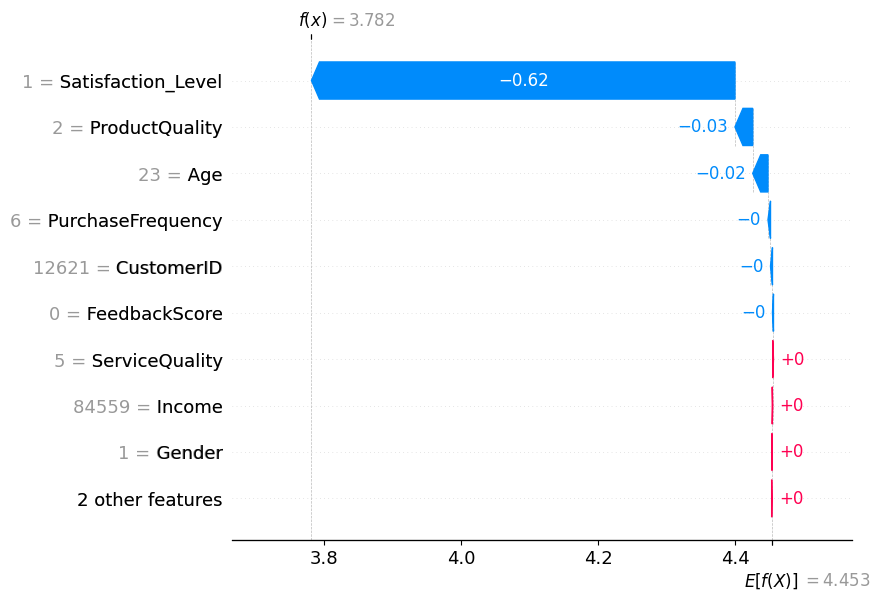

In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import matplotlib.pyplot as plt

# 1. Fungsi objective untuk tuning dengan Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),  # tanpa 'auto'
    }
    model = RandomForestRegressor(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error')
    return -1.0 * score.mean()


# 2. Jalankan tuning
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# 3. Bangun model lagi dengan best params dari Optuna
best_params = study.best_params
best_rf = RandomForestRegressor(**best_params, random_state=42)
best_rf.fit(X_train, y_train)

# 4. Prediksi dan evaluasi
y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("Evaluasi Model Terbaik:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

# 5. Penjelasan prediksi dengan SHAP
explainer = shap.Explainer(best_rf, X_train)
shap_values = explainer(X_test)

# Visualisasi prediksi individual pertama
shap.plots.waterfall(shap_values[0])

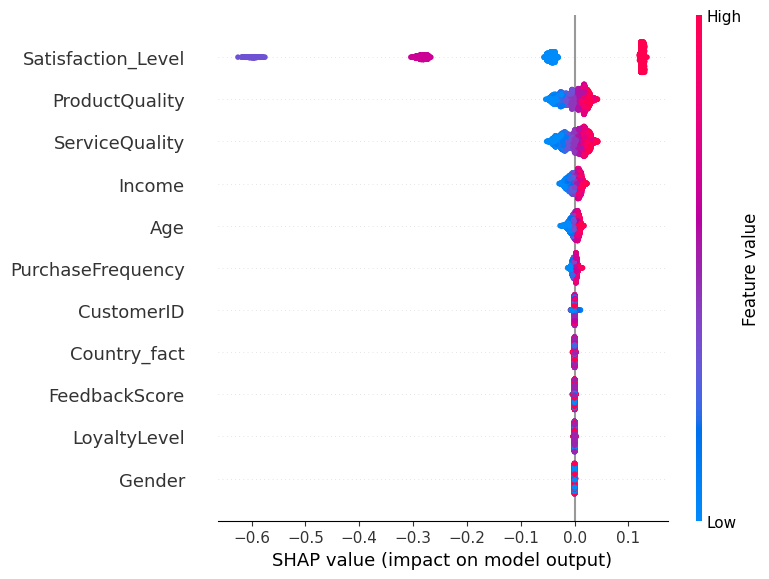

<Figure size 800x650 with 0 Axes>

In [ ]:
# 6. SHAP Summary Plot (semua fitur di test set)
shap.summary_plot(shap_values, X_test)

# Jika ingin disimpan ke file:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary_plot.png", bbox_inches="tight")
plt.clf()  # bersihkan plot agar tidak tumpang tindih

# 7. Simpan waterfall plot observasi pertama
shap.plots.waterfall(shap_values[0], show=False)
plt.savefig("shap_waterfall_plot_obs0.png", bbox_inches="tight")
plt.clf()

# 8. (Opsional) Simpan SHAP values ke DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df['prediction'] = y_pred
shap_df['actual'] = y_test.reset_index(drop=True)  # jika y_test masih dalam bentuk Series

# Simpan ke Excel/CSV jika diperlukan
shap_df.to_csv("shap_values_output.csv", index=False)


 Kesimpulan:
Fitur Satisfaction_Level adalah yang paling dominan dalam prediksi model kamu.

Nilai SHAP negatif untuk fitur ini menunjukkan bahwa nilai rendah dari fitur ini mendorong prediksi menjadi lebih rendah.

Beberapa fitur lain nyaris tak berdampak dan bisa dipertimbangkan untuk dieliminasi agar model lebih sederhana.




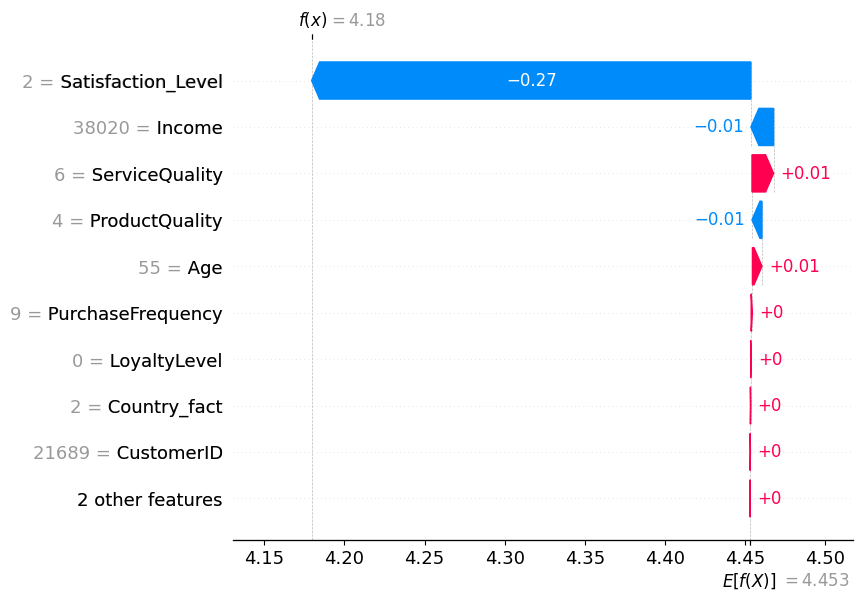

In [ ]:
shap.plots.waterfall(shap_values[10])  # untuk observasi ke-10

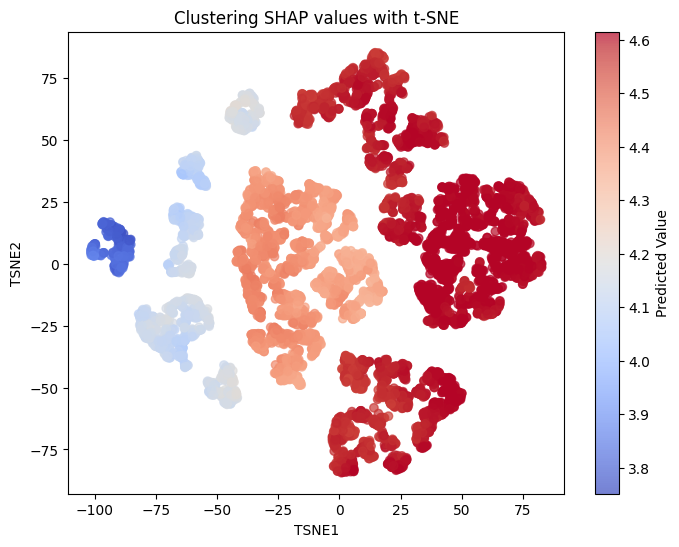

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd

# Ambil nilai SHAP dari beberapa fitur utama saja (untuk efisiensi visualisasi)
shap_array = shap_values.values  # Matrix SHAP (n_samples x n_features)

# Gunakan TSNE untuk reduksi dimensi ke 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
shap_tsne = tsne.fit_transform(shap_array)

# Buat DataFrame untuk visualisasi
df_tsne = pd.DataFrame(shap_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["predicted"] = y_pred  # Bisa juga tambahkan label asli y_test

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne["TSNE1"], df_tsne["TSNE2"], c=df_tsne["predicted"], cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Predicted Value")
plt.title("Clustering SHAP values with t-SNE")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()


Segmentasi berdasarkan alasan ketidakpuasan atau kepuasan.
Kamu bisa fokus ke cluster biru → cari tahu apa yang menyebabkan skor prediksi mereka rendah.

Lalu, bandingkan dengan cluster merah → apa yang membuat mereka puas?

2. Menemukan persona atau target improvement
Contoh: "Pelanggan muda dengan pendapatan rendah dan rendahnya Satisfaction_Level serta ProductQuality termasuk dalam cluster biru → perlu perhatian khusus."

Segmentasi pelanggan berdasarkan SHAP clustering (dari t-SNE plot)
→ Menunjukkan kelompok pelanggan dengan tingkat prediksi kepuasan yang serupa.

Karakteristik setiap segmen
→ Misalnya: segmen A = pelanggan dengan kepuasan tinggi karena Satisfaction_Level dan ServiceQuality tinggi.

Insight actionable
→ Contoh: “Segmen biru memiliki kepuasan rendah; faktor dominan: Satisfaction_Level rendah → perbaiki pelayanan.”